***STEP 1 - Import librerie e recap caratteristiche dataset***

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset_clean.csv")

print(f"Righe: {len(df):,}")
print(f"Colonne: {list(df.columns)}")
print(f"\nDistribuzione priorita_finale:")
print(df['priorita_finale'].value_counts().sort_index())
print(f"\nNaN per colonna:")
print(df.isnull().sum())

Righe: 58,385
Colonne: ['url_ticket', 'case_number', 'testo_input', 'priorita_finale', 'priorita_iniziale_cliente', 'area', 'articolo', 'modulo_sw', 'has_caps', 'has_urgenza', 'has_scadenza', 'data_creazione']

Distribuzione priorita_finale:
priorita_finale
P1     8131
P2    16998
P3    31783
P4     1473
Name: count, dtype: int64

NaN per colonna:
url_ticket                      0
case_number                     0
testo_input                     0
priorita_finale                 0
priorita_iniziale_cliente       0
area                         5847
articolo                     5879
modulo_sw                    5805
has_caps                        0
has_urgenza                     0
has_scadenza                    0
data_creazione                  0
dtype: int64


***STEP 2 — Split temporale train/test***

In [2]:
# Convertiamo data_creazione in datetime
df['data_creazione'] = pd.to_datetime(df['data_creazione'])

# Soglia di split: 1 Novembre 2025
SOGLIA = pd.Timestamp('2025-11-01')

df_train = df[df['data_creazione'] < SOGLIA].copy()
df_test  = df[df['data_creazione'] >= SOGLIA].copy()

print(f"Train: {len(df_train):,} ticket ({len(df_train)/len(df)*100:.1f}%)")
print(f"Test:  {len(df_test):,} ticket ({len(df_test)/len(df)*100:.1f}%)")

print(f"\nTrain — distribuzione priorita_finale:")
print(df_train['priorita_finale'].value_counts().sort_index())

print(f"\nTest — distribuzione priorita_finale:")
print(df_test['priorita_finale'].value_counts().sort_index())

Train: 46,353 ticket (79.4%)
Test:  12,032 ticket (20.6%)

Train — distribuzione priorita_finale:
priorita_finale
P1     6510
P2    13665
P3    24958
P4     1220
Name: count, dtype: int64

Test — distribuzione priorita_finale:
priorita_finale
P1    1621
P2    3333
P3    6825
P4     253
Name: count, dtype: int64


***STEP 3 — Preprocessing features***

In [3]:
from sklearn.preprocessing import OneHotEncoder
import scipy.sparse as sp

# Colonne categoriche e booleane
CAT_COLS  = ['area', 'modulo_sw', 'priorita_iniziale_cliente']
BOOL_COLS = ['has_caps', 'has_urgenza', 'has_scadenza']

# Sostituiamo i NaN nelle categoriche con "sconosciuto"
for col in CAT_COLS:
    df_train[col] = df_train[col].fillna('sconosciuto')
    df_test[col]  = df_test[col].fillna('sconosciuto')

# One-Hot Encoding — fit solo su train, transform su entrambi
# handle_unknown='ignore': se nel test appare una categoria
# mai vista nel train, la ignora invece di dare errore
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
encoder.fit(df_train[CAT_COLS])

X_cat_train = encoder.transform(df_train[CAT_COLS])
X_cat_test  = encoder.transform(df_test[CAT_COLS])

# Feature booleane — già 0/1, le convertiamo in matrice sparsa
X_bool_train = sp.csr_matrix(df_train[BOOL_COLS].values)
X_bool_test  = sp.csr_matrix(df_test[BOOL_COLS].values)

print(f"Feature categoriche encoded: {X_cat_train.shape[1]} colonne")
print(f"Feature booleane:            {X_bool_train.shape[1]} colonne")

Feature categoriche encoded: 256 colonne
Feature booleane:            3 colonne


***STEP 4 — Embedding del testo con Sentence Transformer***

In [ ]:
from sentence_transformers import SentenceTransformer

# Carichiamo il modello multilingue
# paraphrase-multilingual-mpnet-base-v2 è addestrato su 50 lingue
# incluso l'italiano, e produce vettori da 768 dimensioni
modello = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

print("Calcolo embedding train...")
X_text_train = modello.encode(
    df_train['testo_input'].tolist(),
    batch_size=64,
    show_progress_bar=True
)

print("Calcolo embedding test...")
X_text_test = modello.encode(
    df_test['testo_input'].tolist(),
    batch_size=64,
    show_progress_bar=True
)

print(f"\nShape embedding train: {X_text_train.shape}")
print(f"Shape embedding test:  {X_text_test.shape}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Calcolo embedding train...


Batches:   0%|          | 0/725 [00:00<?, ?it/s]

Calcolo embedding test...


Batches:   0%|          | 0/188 [00:00<?, ?it/s]

In [ ]:
# Salva embedding modello attuale (paraphrase-multilingual-mpnet-base-v2)
np.save('X_text_train_mpnet.npy', X_text_train)
np.save('X_text_test_mpnet.npy', X_text_test)
print("Embedding mpnet salvati ✅")

In [ ]:
# Calcolo embedding con modello alternativo
# intfloat/multilingual-e5-base — ottimizzato per classificazione
# Differenza chiave: va prefissato il testo con "query: " 
# è un requisito del modello e migliora le performance
modello_e5 = SentenceTransformer('intfloat/multilingual-e5-base')

X_text_train_e5 = modello_e5.encode(
    ["query: " + t for t in df_train['testo_input'].tolist()],
    batch_size=64,
    show_progress_bar=True
)

X_text_test_e5 = modello_e5.encode(
    ["query: " + t for t in df_test['testo_input'].tolist()],
    batch_size=64,
    show_progress_bar=True
)

np.save('X_text_train_e5.npy', X_text_train_e5)
np.save('X_text_test_e5.npy', X_text_test_e5)
print("Embedding e5 salvati ✅")

***STEP 5 — Unione di tutte le feature in un'unica matrice***

In [ ]:
import scipy.sparse as sp
import numpy as np

# Convertiamo gli embedding (numpy array) in matrice sparsa
# per renderli compatibili con X_cat e X_bool che sono già sparse
X_text_train_sp = sp.csr_matrix(X_text_train)
X_text_test_sp  = sp.csr_matrix(X_text_test)

# hstack = horizontal stack — unisce le matrici colonna per colonna
X_train = sp.hstack([X_text_train_sp, X_cat_train, X_bool_train])
X_test  = sp.hstack([X_text_test_sp,  X_cat_test,  X_bool_test])

# Target
y_train = df_train['priorita_finale'].values
y_test  = df_test['priorita_finale'].values

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train classi: {np.unique(y_train)}")

ValueError: Mismatching dimensions along axis 0: {46361, 46353}

In [ ]:
# STEP 6 — Training classificatore priorità
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# class_weight='balanced' — compensa lo sbilanciamento tra classi
# max_iter=2000 — aumentiamo le iterazioni per garantire convergenza
clf = LinearSVC(class_weight='balanced', max_iter=2000)
clf.fit(X_train, y_train)

# Valutazione sul test set
y_pred = clf.predict(X_test)

print("=== RISULTATI CLASSIFICATORE PRIORITÀ ===")
print(classification_report(y_test, y_pred))

ValueError: Found input variables with inconsistent numbers of samples: [46361, 46353]

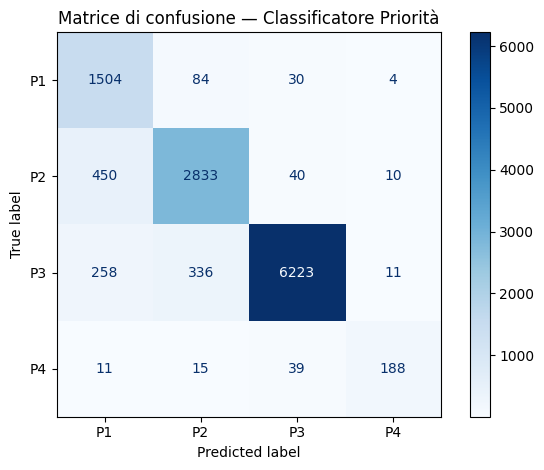

In [ ]:
# Matrice di confusione
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=['P1', 'P2', 'P3', 'P4'],
    cmap='Blues'
)
plt.title('Matrice di confusione — Classificatore Priorità')
plt.tight_layout()
plt.show()